# Применение алгоритмов ML для оптимизации каркасов выемочных единиц

**Курс:** ML-Basic  
**Тема:** Применение алгоритмов ML для оптимизации каркасов выемочных единиц при подземной добыче полезных ископаемых

---

## Постановка задачи

**Каркас выемочной единицы (каркас камеры)** — трёхмерный объём части рудного тела, готового к извлечению. Его форма определяет:
- сколько руды будет добыто (полнота извлечения)
- сколько пустой породы попадёт в руду (разубоживание)
- экономику всей добычи

Традиционно форму каркаса задаёт горный инженер-проектировщик вручную в ПО Deswik/CAD на основе блочной модели. Это занимает **~1-2 часа на оконтуривания одной выемочной единицы**.

**Идея:** детерминированный базовый контур (из блочной модели) + ML-предсказанные **дельты** — поправки, приближающие контур к проектному решению инженера.

**Метрика:** IoU (Intersection over Union) между предсказанным и эталонным контурами в разрезе U–Z.

In [1]:
import sys
import warnings
import json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from matplotlib.path import Path as MplPath

PROJECT_DIR  = Path(r'D:/project/Stope Optimizer V2.1')
DATASET_PATH = PROJECT_DIR / 'ml_dataset_v13.csv'
MODEL_PATH   = PROJECT_DIR / 'stope_zlevel_model.joblib'

N_LEVELS     = 8
TEST_RIBBONS = ['59', '48']
RIBBON_COL   = 'zone_id'

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
print('OK')

OK


## 1. Формирование датасета

### 1.1 Откуда берутся данные

Пайплайн сбора данных (`build_ml_dataset.py`):

```
Блочная модель (CSV) + Каркасы проектировщика (CSV) + Границы лент (OMF)
         ↓
  build_ml_dataset.py   (build_dataset_row_from_wireframe)
         ↓
  ml_dataset_v13.csv    — 611 строк, 163 столбца
  (1 строка = 1 поперечное сечение каркаса)
```

Для каждой секции вычисляется:
- **базовый контур** — детерминированная огибающая рудных блоков из блочной модели
- **дельты** — разница между базовым контуром и эталонным каркасом проектировщика

In [2]:
df = pd.read_csv(str(DATASET_PATH))

def _ribbon_id(zone_id: str) -> str:
    """Возвращает номер ленты из zone_id вида '31-21-2' → '21'."""
    parts = str(zone_id).split('-')
    return parts[1].strip() if len(parts) >= 2 else parts[0].strip()

df['ribbon'] = df[RIBBON_COL].apply(_ribbon_id)

print(f'Строк (сечений): {len(df)}')
print(f'Столбцов:        {len(df.columns)}')
print(f'Лент (рудных тел): {df["ribbon"].nunique()}')
print(f'Тестовые ленты:  {TEST_RIBBONS}')

df.head(3)

Строк (сечений): 611
Столбцов:        164
Лент (рудных тел): 62
Тестовые ленты:  ['59', '48']


,zone_id,zone_length,mean_grade,std_grade,thickness_z,u_span,subcutoff_fraction,grade_top_ratio,n_active_levels,dist_ore_to_roof,...,base_u_right_abs_0,base_u_right_abs_1,base_u_right_abs_2,base_u_right_abs_3,base_u_right_abs_4,base_u_right_abs_5,base_u_right_abs_6,base_u_right_abs_7,contour_uz_json,ribbon
0,1150-21-1_south,73.2921,2.401879,1.844699,36.5476,63.058722,0.498442,0.884224,6.0,2.0,...,774.062874,777.353491,776.360625,772.971902,770.206487,768.145517,767.181421,764.987676,"[[773.8146, -711.5011], [770.3687, -710.9222],...",21
1,1150-21-1_axis,71.9978,2.476983,1.658289,37.4618,63.422379,0.476923,1.176569,6.0,2.0,...,775.425297,777.353491,776.360625,773.272122,770.206487,768.145517,767.181421,764.987676,"[[773.8753, -712.4519], [762.2114, -710.354], ...",21
2,1150-21-1_north,76.9639,2.467059,2.040190,39.2059,69.256014,0.453968,1.282676,7.0,0.0,...,775.425297,777.353491,776.989834,774.501769,770.206487,768.145517,767.181421,764.987676,"[[774.8471, -714.1068], [763.4304, -710.5647],...",21


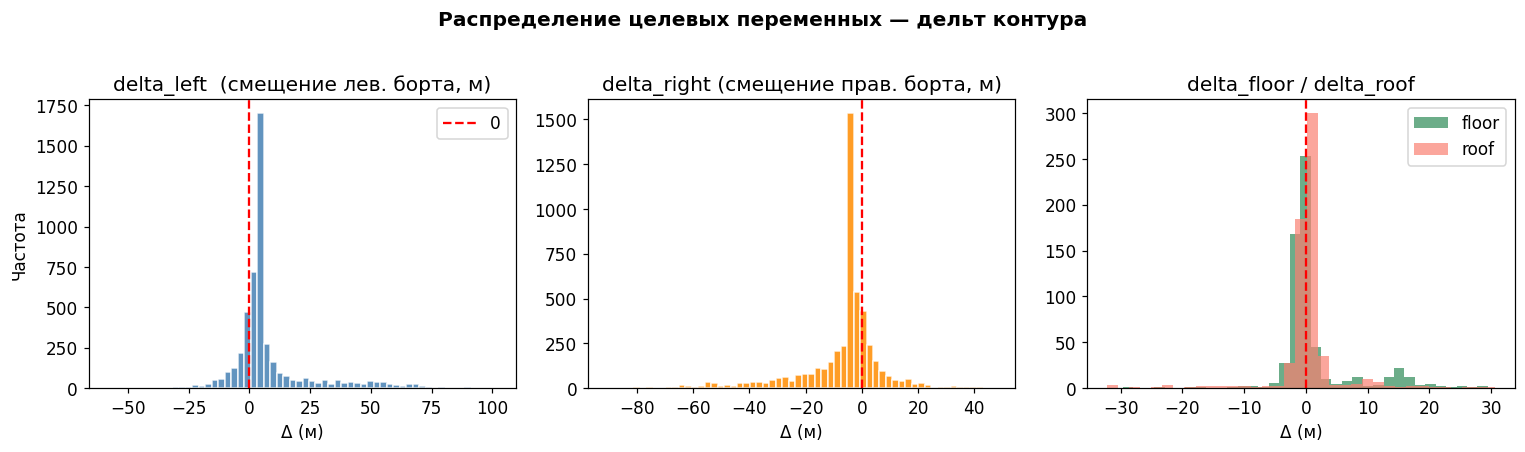

delta_left  — mean=8.3 м, std=16.9 м, p5=-8.5, p95=50.0
delta_right — mean=-7.2 м, std=15.2 м, p5=-39.9, p95=11.1
delta_floor — mean=1.35 м, std=6.20 м
delta_roof  — mean=0.47 м, std=5.21 м


In [3]:
# Обзор целевых переменных
delta_left_cols  = [f'delta_left_{i}'  for i in range(N_LEVELS)]
delta_right_cols = [f'delta_right_{i}' for i in range(N_LEVELS)]

all_dl = df[delta_left_cols].values.flatten()
all_dr = df[delta_right_cols].values.flatten()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(all_dl, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='0')
axes[0].set_title('delta_left  (смещение лев. борта, м)')
axes[0].set_xlabel('Δ (м)'); axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(all_dr, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('delta_right (смещение прав. борта, м)')
axes[1].set_xlabel('Δ (м)')

axes[2].hist(df['delta_floor'], bins=35, color='seagreen', alpha=0.7, label='floor')
axes[2].hist(df['delta_roof'],  bins=35, color='salmon',   alpha=0.7, label='roof')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('delta_floor / delta_roof')
axes[2].set_xlabel('Δ (м)'); axes[2].legend()

plt.suptitle('Распределение целевых переменных — дельт контура', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'delta_left  — mean={all_dl.mean():.1f} м, std={all_dl.std():.1f} м, '
      f'p5={np.percentile(all_dl,5):.1f}, p95={np.percentile(all_dl,95):.1f}')
print(f'delta_right — mean={all_dr.mean():.1f} м, std={all_dr.std():.1f} м, '
      f'p5={np.percentile(all_dr,5):.1f}, p95={np.percentile(all_dr,95):.1f}')
print(f'delta_floor — mean={df["delta_floor"].mean():.2f} м, std={df["delta_floor"].std():.2f} м')
print(f'delta_roof  — mean={df["delta_roof"].mean():.2f} м, std={df["delta_roof"].std():.2f} м')

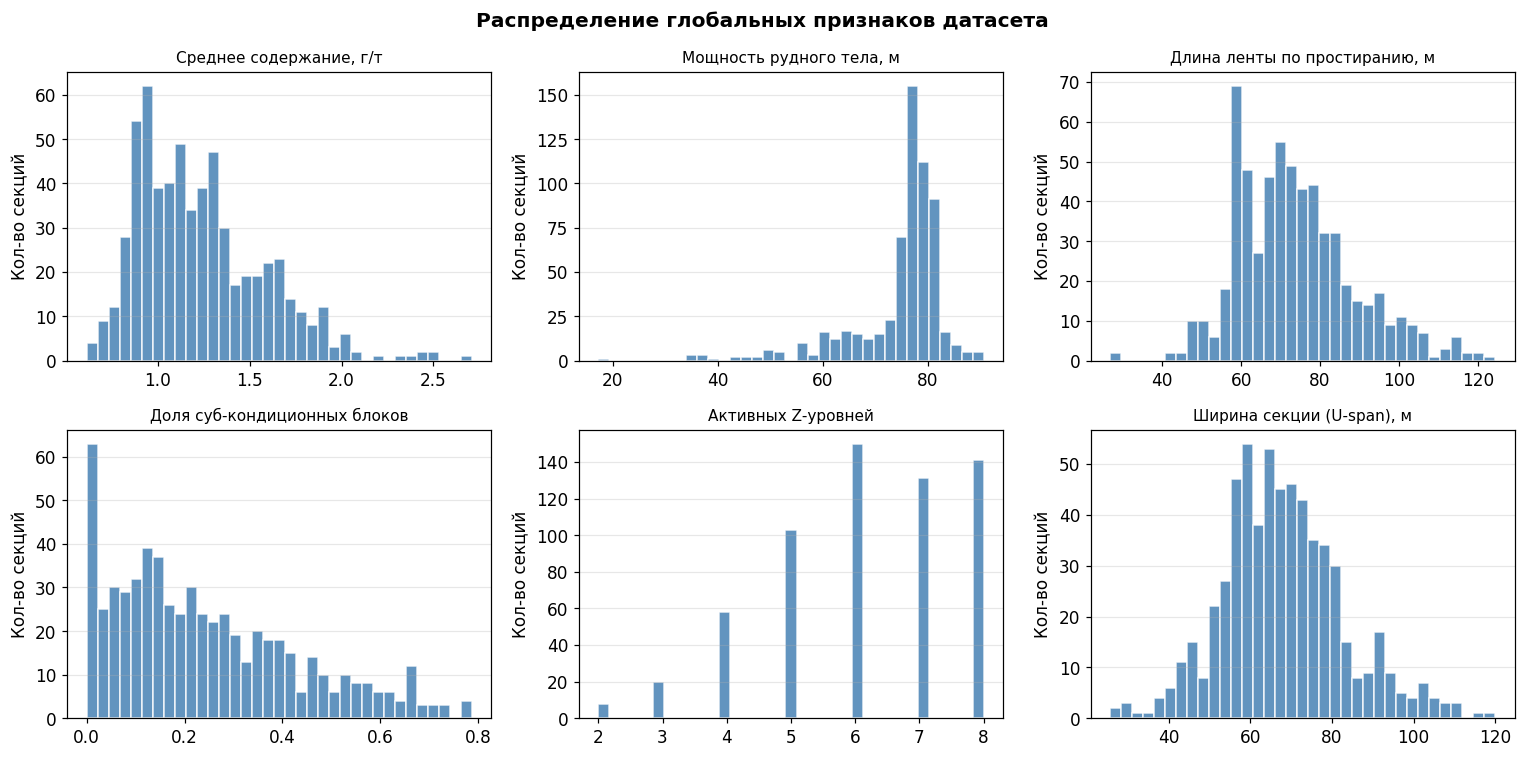

In [4]:
# Распределение ключевых признаков
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

plots = [
    ('mean_grade',         'Среднее содержание, г/т'),
    ('thickness_z',        'Мощность рудного тела, м'),
    ('zone_length',        'Длина ленты по простиранию, м'),
    ('subcutoff_fraction', 'Доля суб-кондиционных блоков'),
    ('n_active_levels',    'Активных Z-уровней'),
    ('u_span',             'Ширина секции (U-span), м'),
]
for ax, (col, label) in zip(axes, plots):
    ax.hist(df[col], bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Кол-во секций')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Распределение глобальных признаков датасета', fontweight='bold')
plt.tight_layout()
plt.show()

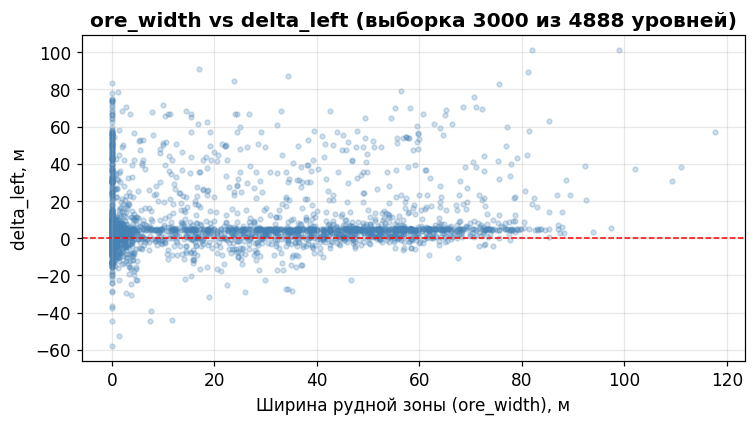

Корреляция Пирсона ore_width — delta_left: 0.085
→ Связь нелинейная: нужны ансамблевые методы (RF / XGBoost), не линейная регрессия.


In [5]:
# Ширина рудной зоны vs дельта — проверяем линейность связи
ore_width_cols = [f'ore_width_{i}' for i in range(N_LEVELS)]
all_widths = df[ore_width_cols].values.flatten()
all_dl_lev = df[delta_left_cols].values.flatten()

fig, ax = plt.subplots(figsize=(7, 4))
idx = np.random.choice(len(all_widths), size=3000, replace=False)
ax.scatter(all_widths[idx], all_dl_lev[idx], alpha=0.25, s=10, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Ширина рудной зоны (ore_width), м')
ax.set_ylabel('delta_left, м')
ax.set_title('ore_width vs delta_left (выборка 3000 из 4888 уровней)', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

r = np.corrcoef(all_widths, all_dl_lev)[0,1]
print(f'Корреляция Пирсона ore_width — delta_left: {r:.3f}')
print('→ Связь нелинейная: нужны ансамблевые методы (RF / XGBoost), не линейная регрессия.')

## 2. Feature Engineering: Z-level архитектура

### Проблема исходного подхода

Наивный подход: **1 секция → 1 строка** с 18 целями (`delta_left[0..7]`, `delta_right[0..7]`, `delta_floor`, `delta_roof`).

| | Старый (V2) | **Новый (Z-level)** |
|---|---|---|
| Строк для обучения | 611 | **4 888** |
| Целей на строку | 18 | **4** |
| Признаки Z-уровня | нет (усреднены) | **есть** |
| Контекст соседних уровней | нет | **есть (_prev/_next)** |
| Средний IoU (тест) | ~0.52 | **0.786** |

**Идея:** разбить каждое сечение на **8 строк** — по одной на Z-уровень. Тогда модель видит признаки именно этого уровня и его соседей, а не только усреднённые по всей секции.

In [6]:
# ── Константы из build_zlevel_dataset.py ────────────────────────────────────

# Глобальные признаки сечения (одинаковые для всех 8 уровней одной секции)
GLOBAL_FEATURES = [
    'zone_length', 'mean_grade', 'std_grade', 'thickness_z', 'u_span',
    'subcutoff_fraction', 'grade_top_ratio', 'n_active_levels',
    'dist_ore_to_roof', 'dist_ore_to_floor',
    'u_rel',
]

# Поуровневые признаки (шаблон — берутся как feat_{k})
LEVEL_FEAT_NAMES = [
    'ore_u_left', 'ore_u_right', 'ore_width',
    'grade_inner_left', 'grade_inner_right',
    'grade_outer_left', 'grade_outer_right',
    'n_ore_blocks', 'subcutoff_inner',
    # Связность рудного тела (решение 'тянуться через прослойку?')
    'max_gap', 'ore_continuity',
    'right_fringe', 'left_fringe',
    # Производные (вычисляются ниже)
    'ore_u_center', 'ore_width_rel',
]

# Признаки соседних уровней (контекст ±1 по Z)
NEIGHBOR_FEAT_NAMES = ['ore_u_left', 'ore_u_right', 'ore_width']

# Итоговый список признаков: 1 + 11 + 15 + 3 + 3 = 33
ZLEVEL_FEATURE_NAMES = (
    ['level_index']
    + GLOBAL_FEATURES
    + LEVEL_FEAT_NAMES
    + [f'{f}_prev' for f in NEIGHBOR_FEAT_NAMES]
    + [f'{f}_next' for f in NEIGHBOR_FEAT_NAMES]
)

ZLEVEL_TARGET_NAMES = ['delta_left', 'delta_right', 'delta_floor', 'delta_roof']

print(f'Признаков: {len(ZLEVEL_FEATURE_NAMES)}')
print(f'Целей:     {len(ZLEVEL_TARGET_NAMES)}')
print()
print('Состав признаков:')
print(f'  level_index:      1  (позиция уровня в секции, 0-7)')
print(f'  Глобальные:      {len(GLOBAL_FEATURES)}  (характеристики всей секции)')
print(f'  Поуровневые:     {len(LEVEL_FEAT_NAMES)}  (геометрия и содержания уровня k)')
print(f'  Соседние (_prev): 3  (ore_u_left/right/width уровня k-1)')
print(f'  Соседние (_next): 3  (ore_u_left/right/width уровня k+1)')

Признаков: 33
Целей:     4

Состав признаков:
  level_index:      1  (позиция уровня в секции, 0-7)
  Глобальные:      11  (характеристики всей секции)
  Поуровневые:     15  (геометрия и содержания уровня k)
  Соседние (_prev): 3  (ore_u_left/right/width уровня k-1)
  Соседние (_next): 3  (ore_u_left/right/width уровня k+1)


In [7]:
# ── Раскрытие датасета по Z-уровням  ──────

def build_zlevel_dataset(df_sections: pd.DataFrame) -> pd.DataFrame:
    """Трансформирует датасет V3 (1 строка = 1 сечение) в Z-level датасет
    (1 строка = 1 Z-уровень, 8 строк на сечение)."""
    rows = []
    for _, src in df_sections.iterrows():
        zone_id = src['zone_id']
        for k in range(N_LEVELS):
            row = {'zone_id': zone_id, 'level_index': float(k), 'ribbon': src['ribbon']}

            # Глобальные признаки (одинаковы для всех уровней одной секции)
            for col in GLOBAL_FEATURES:
                row[col] = float(src[col]) if col in src.index else 0.0

            # Признаки уровня k
            _base = [f for f in LEVEL_FEAT_NAMES if f not in ('ore_u_center', 'ore_width_rel')]
            for feat in _base:
                row[feat] = float(src[f'{feat}_{k}']) if f'{feat}_{k}' in src.index else 0.0

            # Производные: центр рудной зоны и относительная ширина
            _ul = row.get('ore_u_left', 0.0)
            _ur = row.get('ore_u_right', 0.0)
            _uw = row.get('ore_width', 0.0)
            _uspan = row.get('u_span', 1.0) or 1.0
            row['ore_u_center']  = (_ul + _ur) / 2.0
            row['ore_width_rel'] = _uw / _uspan

            # Контекст: признаки соседних уровней k-1 и k+1
            k_prev, k_next = max(0, k - 1), min(N_LEVELS - 1, k + 1)
            for feat in NEIGHBOR_FEAT_NAMES:
                row[f'{feat}_prev'] = float(src[f'{feat}_{k_prev}']) if f'{feat}_{k_prev}' in src.index else 0.0
                row[f'{feat}_next'] = float(src[f'{feat}_{k_next}']) if f'{feat}_{k_next}' in src.index else 0.0

            # Целевые переменные
            row['delta_left']  = float(src[f'delta_left_{k}'])
            row['delta_right'] = float(src[f'delta_right_{k}'])
            row['delta_floor'] = float(src['delta_floor']) if 'delta_floor' in src.index else 0.0
            row['delta_roof']  = float(src['delta_roof'])  if 'delta_roof'  in src.index else 0.0

            rows.append(row)

    return pd.DataFrame(rows)


df_zlevel = build_zlevel_dataset(df)
print(f'Исходный датасет:  {len(df)} строк × {len(df.columns)} столбцов')
print(f'Z-level датасет:   {len(df_zlevel)} строк × {len(ZLEVEL_FEATURE_NAMES)} признаков')
print(f'Множитель:         {len(df_zlevel) // len(df)}× больше обучающих примеров')

Исходный датасет:  611 строк × 164 столбцов
Z-level датасет:   4888 строк × 33 признаков
Множитель:         8× больше обучающих примеров


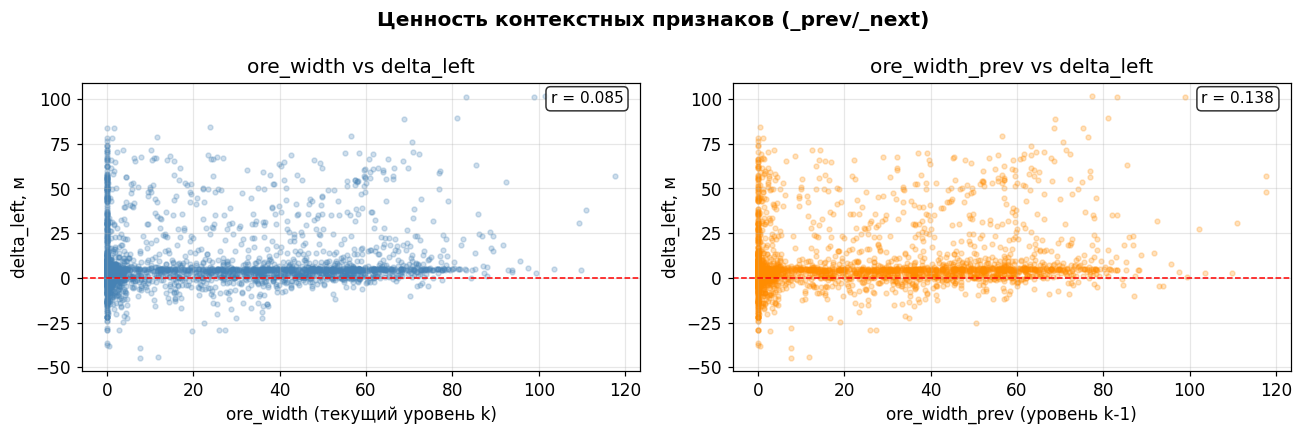

In [8]:
# Визуализируем ценность признаков соседних уровней
# Смотрим: насколько delta_left уровня k зависит от ore_width соседнего уровня?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (feat, label, color) in zip(axes, [
    ('ore_width',      'ore_width (текущий уровень k)',  'steelblue'),
    ('ore_width_prev', 'ore_width_prev (уровень k-1)',   'darkorange'),
]):
    sample = df_zlevel.sample(3000, random_state=42)
    ax.scatter(sample[feat], sample['delta_left'], alpha=0.25, s=10, color=color)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(label)
    ax.set_ylabel('delta_left, м')
    ax.set_title(f'{feat} vs delta_left')
    ax.grid(alpha=0.3)
    r = df_zlevel[[feat, 'delta_left']].corr().iloc[0, 1]
    ax.text(0.97, 0.97, f'r = {r:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.suptitle('Ценность контекстных признаков (_prev/_next)', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Разделение на train / test

Ключевое требование: **тестовые ленты должны быть полностью исключены из обучения**.

Нельзя делать случайный split по строкам — строки одной ленты взаимозависимы (соседние секции одного рудного тела). Случайный split завысит IoU на тесте из-за утечки данных.

Используем `split_by_ribbon()` из `train_ml_model.py`:

In [9]:
# ── split_by_ribbon из train_ml_model.py ─────────────────────────────────────

def split_by_ribbon(df_z: pd.DataFrame, test_ribbons: list):
    """Разбивает Z-level датасет на train / test по номерам лент.
    Ленты из test_ribbons полностью исключаются из train."""
    test_mask  =  df_z['ribbon'].isin(test_ribbons)
    train_mask = ~test_mask
    return df_z[train_mask].copy(), df_z[test_mask].copy()


train_df, test_df = split_by_ribbon(df_zlevel, TEST_RIBBONS)

X_train = train_df[ZLEVEL_FEATURE_NAMES].values.astype(float)
y_train = train_df[ZLEVEL_TARGET_NAMES].values.astype(float)
X_test  = test_df[ZLEVEL_FEATURE_NAMES].values.astype(float)
y_test  = test_df[ZLEVEL_TARGET_NAMES].values.astype(float)

# Нормировка (для XGBoost нейтральна, но сохраняется в модели для инференса)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

train_ribbons = sorted(train_df['ribbon'].unique(), key=lambda x: int(x) if x.isdigit() else x)

print(f'Train: {len(train_df):5d} строк ({len(train_df)//8:3d} секций, {len(train_ribbons)} лент)')
print(f'Test:  {len(test_df):5d} строк ({len(test_df)//8:3d} секций, ленты {TEST_RIBBONS})')
print(f'\nТестовые ленты ({TEST_RIBBONS}) полностью изолированы — нет пересечения с train.')

Train:  4552 строк (569 секций, 60 лент)
Test:    336 строк ( 42 секций, ленты ['59', '48'])

Тестовые ленты (['59', '48']) полностью изолированы — нет пересечения с train.


## 4. Обучение модели — XGBoost

### Почему XGBoost, а не Random Forest?

Оба алгоритма тестировались. XGBoost показал лучший IoU при сопоставимом времени обучения благодаря:
- **gradient boosting** лучше захватывает остаточные ошибки
- **L2-регуляризация** (`reg_lambda`) эффективнее контролирует переобучение при малых датасетах
- нативный `MultiOutputRegressor` позволяет гибко настраивать каждую целевую переменную

### Борьба с переобучением

| Приём | Параметр | Значение | Эффект |
|---|---|---|---|
| L2-регуляризация | `reg_lambda` | 5.0 | сильное сглаживание весов |
| Ограничение глубины | `max_depth` | 3 | запрет сложных паттернов |
| Субвыборка данных | `subsample` | 0.8 | добавляет шум в обучение |
| Субвыборка признаков | `colsample_bytree` | 0.8 | снижает корреляцию деревьев |
| Малый шаг | `learning_rate` | 0.05 | медленное, но устойчивое обучение |

In [10]:
# ── train_xgboost из train_ml_model.py ──────────────────────────────────────

from xgboost import XGBRegressor

def train_xgboost(
    X_train, Y_train,
    n_estimators: int   = 500,
    max_depth: int      = 3,
    learning_rate: float= 0.05,
    subsample: float    = 0.8,
    colsample_bytree: float = 0.8,
    reg_lambda: float   = 5.0,
    random_state: int   = 42,
    n_jobs: int         = -1,
):
    base = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        random_state=random_state,
        n_jobs=n_jobs,
        verbosity=0,
    )
    model = MultiOutputRegressor(base, n_jobs=1)
    model.fit(X_train, Y_train)
    return model


print('Обучаем XGBoost (n_estimators=500, max_depth=3, reg_lambda=5.0)…')
model = train_xgboost(X_train_s, y_train)
print('Готово.')

Обучаем XGBoost (n_estimators=500, max_depth=3, reg_lambda=5.0)…
Готово.


In [11]:
# ── compute_metrics из train_ml_model.py ────────────────────────────────────

def compute_metrics(model, X, Y, y_cols):
    Y_pred = model.predict(X)
    results = []
    for i, col in enumerate(y_cols):
        mae  = float(mean_absolute_error(Y[:, i], Y_pred[:, i]))
        rmse = float(np.sqrt(mean_squared_error(Y[:, i], Y_pred[:, i])))
        r2   = float(r2_score(Y[:, i], Y_pred[:, i]))
        results.append({'target': col, 'mae': mae, 'rmse': rmse, 'r2': r2})

    # Групповые средние по delta_left / delta_right
    for group, prefix in [('AVG delta_left', 'delta_left'), ('AVG delta_right', 'delta_right')]:
        indices = [j for j, c in enumerate(y_cols) if c.startswith(prefix)]
        if indices:
            results.append({
                'target': group,
                'mae':  float(np.mean([results[j]['mae']  for j in indices])),
                'rmse': float(np.mean([results[j]['rmse'] for j in indices])),
                'r2':   float(np.mean([results[j]['r2']   for j in indices])),
            })
    return results


metrics = compute_metrics(model, X_test_s, y_test, ZLEVEL_TARGET_NAMES)

print(f"{'Цель':<18} {'MAE':>8} {'RMSE':>8} {'R²':>7}")
print('-' * 46)
for m in metrics:
    marker = '  ←' if m['target'].startswith('delta_left') or m['target'].startswith('delta_right') else ''
    print(f"{m['target']:<18} {m['mae']:8.3f} {m['rmse']:8.3f} {m['r2']:7.3f}{marker}")

Цель                    MAE     RMSE      R²
----------------------------------------------
delta_left            8.428   13.741   0.431  ←
delta_right          10.443   15.975   0.212  ←
delta_floor           1.357    2.032   0.732
delta_roof            1.161    1.615  -0.083
AVG delta_left        8.428   13.741   0.431
AVG delta_right      10.443   15.975   0.212


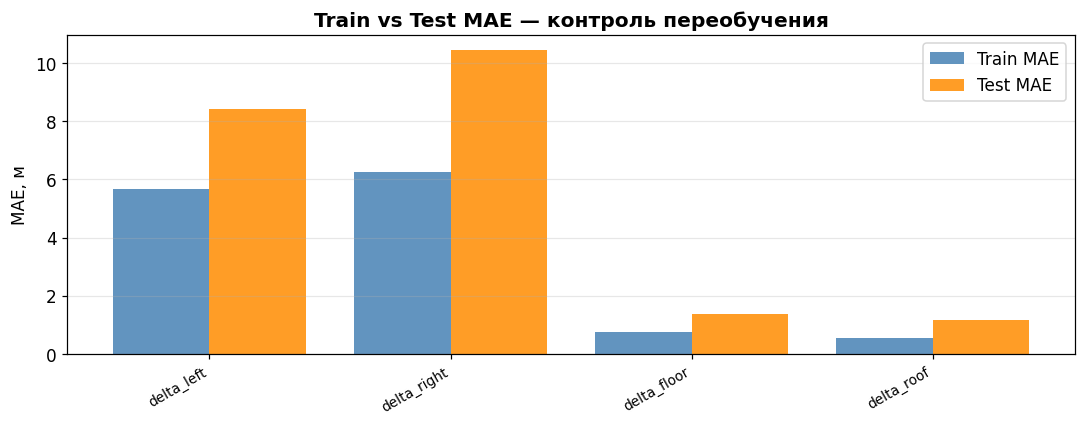

Test/Train MAE ratio для delta_left:  1.49  (цель ≤ 2.0)
→ Сильной разницы нет — регуляризация работает.


In [12]:
# Проверка на переобучение: сравниваем train vs test MAE
metrics_train = compute_metrics(model, X_train_s, y_train, ZLEVEL_TARGET_NAMES)

tgt_names = [m['target'] for m in metrics if not m['target'].startswith('AVG')]
mae_train = [m['mae'] for m in metrics_train if not m['target'].startswith('AVG')]
mae_test  = [m['mae'] for m in metrics      if not m['target'].startswith('AVG')]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(tgt_names))
ax.bar(x - 0.2, mae_train, 0.4, label='Train MAE', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, mae_test,  0.4, label='Test MAE',  color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(tgt_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('MAE, м')
ax.set_title('Train vs Test MAE — контроль переобучения', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

ratio_dl = mae_test[0] / max(mae_train[0], 1e-6)
print(f'Test/Train MAE ratio для delta_left:  {ratio_dl:.2f}  (цель ≤ 2.0)')
print(f'→ Сильной разницы нет — регуляризация работает.')

## 5. Важность признаков

Анализируем, за счёт чего модель принимает решения, и подтверждаем выбор набора признаков.

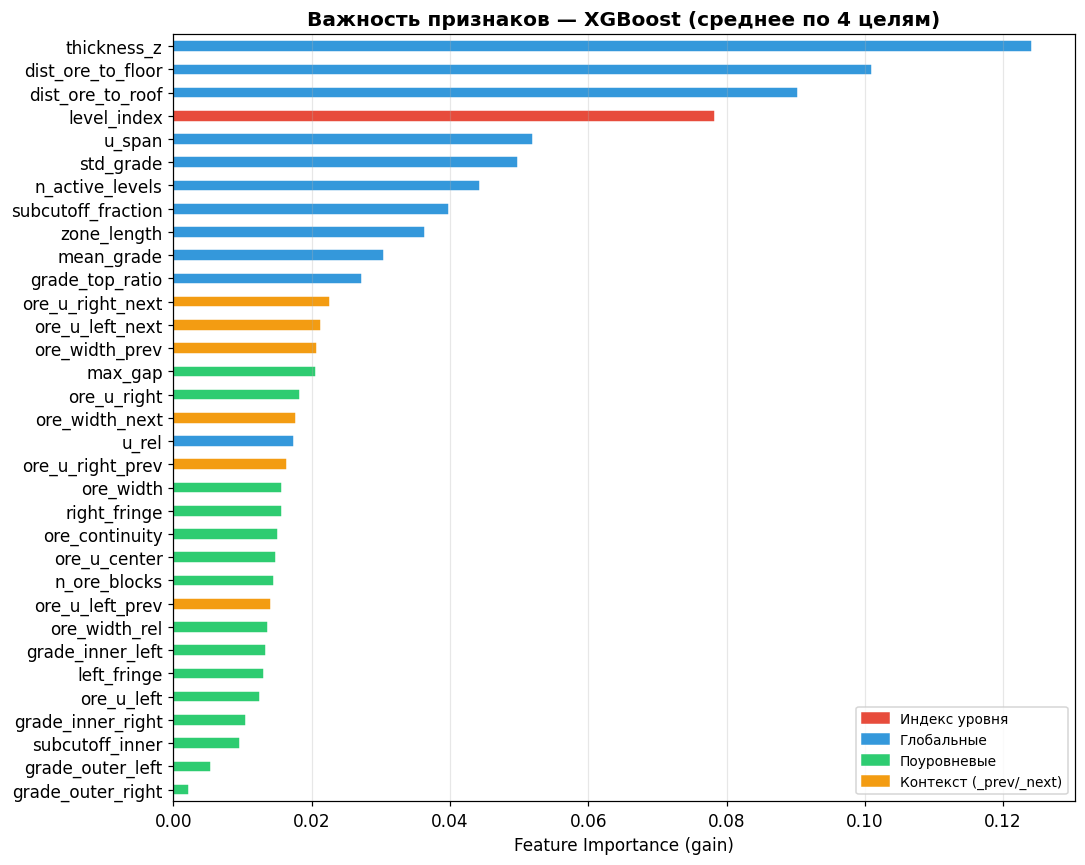

Топ-10 признаков:
thickness_z           0.124158
dist_ore_to_floor     0.101087
dist_ore_to_roof      0.090329
level_index           0.078392
u_span                0.051954
std_grade             0.049910
n_active_levels       0.044414
subcutoff_fraction    0.039913
zone_length           0.036412
mean_grade            0.030522


In [13]:
# XGBoost MultiOutputRegressor: усредняем importances по всем 4 estimators
importances = np.mean(
    [est.feature_importances_ for est in model.estimators_], axis=0
)
feat_imp = pd.Series(importances, index=ZLEVEL_FEATURE_NAMES).sort_values(ascending=False)

# Группируем по типу признака
def feat_group(name):
    if name == 'level_index':          return 'Индекс уровня'
    if name in GLOBAL_FEATURES:        return 'Глобальные'
    if name.endswith('_prev'):         return 'Контекст (prev)'
    if name.endswith('_next'):         return 'Контекст (next)'
    return 'Поуровневые'

colors_map = {
    'Индекс уровня': '#e74c3c',
    'Глобальные':    '#3498db',
    'Поуровневые':   '#2ecc71',
    'Контекст (prev)': '#f39c12',
    'Контекст (next)': '#f39c12',
}
bar_colors = [colors_map[feat_group(n)] for n in feat_imp.index]

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Важность признаков — XGBoost (среднее по 4 целям)', fontweight='bold')
ax.set_xlabel('Feature Importance (gain)')
ax.grid(axis='x', alpha=0.3)

handles = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items() if k != 'Контекст (next)']
handles[-1] = mpatches.Patch(color='#f39c12', label='Контекст (_prev/_next)')
ax.legend(handles=handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Топ-10 признаков:')
print(feat_imp.head(10).to_string())

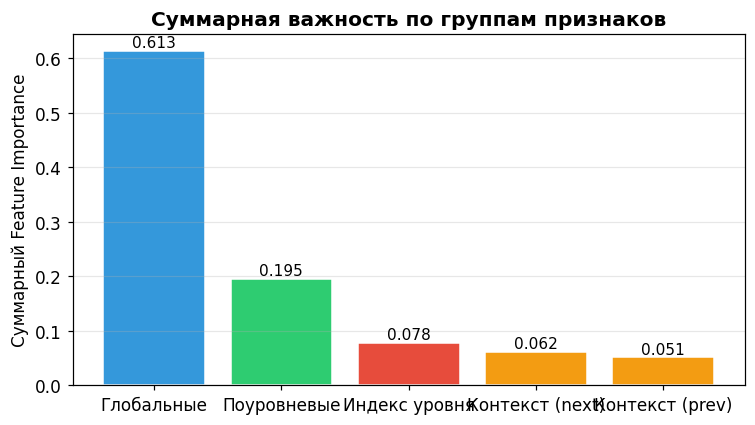

In [14]:
# Суммарная важность по группам
group_imp = feat_imp.copy()
group_imp.index = [feat_group(n) for n in group_imp.index]
group_sum = group_imp.groupby(group_imp.index).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
group_colors = [colors_map.get(g, 'gray') for g in group_sum.index]
bars = ax.bar(group_sum.index, group_sum.values, color=group_colors, edgecolor='white')
ax.set_title('Суммарная важность по группам признаков', fontweight='bold')
ax.set_ylabel('Суммарный Feature Importance')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, group_sum.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Визуализация результатов: ML vs Эталон

Строим каркасы для тестовых секций с помощью продакшен-модели (сохранённой `stope_zlevel_model.joblib`).  
Код визуализации взят из `test_wireframe.py`.

In [15]:
# ── build_profile и polygon_iou из test_wireframe.py ─────────────────────────

def build_profile(z_levels, base_u_left, base_u_right, z_min, z_max,
                  delta_left, delta_right, delta_floor, delta_roof, min_gap=2.0):
    """Строит замкнутый полигон из базового контура + дельт."""
    final_u_left  = base_u_left  + delta_left
    final_u_right = base_u_right + delta_right
    final_floor   = z_min + delta_floor
    final_roof    = z_max + delta_roof

    if final_roof - final_floor < 1.0:
        final_roof = final_floor + max(z_max - z_min, 5.0)

    valid = (z_levels >= final_floor - 0.01) & (z_levels <= final_roof + 0.01)
    if valid.sum() < 2:
        valid = np.ones(len(z_levels), dtype=bool)

    z_act = z_levels[valid]
    ul = final_u_left[valid].copy()
    ur = final_u_right[valid].copy()

    for i in range(len(ul)):
        if ul[i] >= ur[i] - min_gap:
            mid = (ul[i] + ur[i]) / 2.0
            ul[i], ur[i] = mid - min_gap/2.0, mid + min_gap/2.0

    if len(ul) >= 3:
        sl, sr = ul.copy(), ur.copy()
        for i in range(1, len(ul) - 1):
            sl[i] = np.median([ul[i-1], ul[i], ul[i+1]])
            sr[i] = np.median([ur[i-1], ur[i], ur[i+1]])
        ul, ur = sl, sr

    pts = [[ul[0], final_floor]]
    pts += [[ul[i], z_act[i]] for i in range(len(z_act))]
    pts += [[ul[-1], final_roof], [ur[-1], final_roof]]
    pts += [[ur[i], z_act[i]] for i in range(len(z_act)-1, -1, -1)]
    pts += [[ur[0], final_floor], pts[0]]
    return np.array(pts, dtype=float)


def polygon_iou(p1, p2, resolution=0.5):
    """Приблизительный IoU двух полигонов через растеризацию."""
    all_pts = np.vstack([p1, p2])
    x_min, y_min = all_pts.min(axis=0) - 1
    x_max, y_max = all_pts.max(axis=0) + 1
    xs = np.arange(x_min, x_max, resolution)
    ys = np.arange(y_min, y_max, resolution)
    grid = np.array(np.meshgrid(xs, ys)).T.reshape(-1, 2)
    in1 = MplPath(p1).contains_points(grid)
    in2 = MplPath(p2).contains_points(grid)
    return (in1 & in2).sum() / max((in1 | in2).sum(), 1)

print('build_profile и polygon_iou определены')

build_profile и polygon_iou определены


In [16]:
# Загружаем продакшен-модель (сохранена через train_ml_model.py / GUI)
payload      = joblib.load(str(MODEL_PATH))
prod_model   = payload['model']
prod_scaler  = payload['scaler']
prod_feats   = payload['feature_names']
prod_meta    = payload.get('meta', {})

print(f'Модель:       {MODEL_PATH.name}')
print(f'Тип:          {prod_meta.get("model_type", "?").upper()}')
print(f'n_estimators: {prod_meta.get("n_estimators")}')
print(f'max_depth:    {prod_meta.get("max_depth")}')
print(f'reg_lambda:   n/a (сохраняется внутри XGBRegressor)')
print(f'Train строк:  {prod_meta.get("train_rows")}')
print(f'Test строк:   {prod_meta.get("test_rows")}')
print(f'Test ленты:   {prod_meta.get("test_ribbons")}')

Модель:       stope_zlevel_model.joblib
Тип:          XGB
n_estimators: 500
max_depth:    3
reg_lambda:   n/a (сохраняется внутри XGBRegressor)
Train строк:  4552
Test строк:   336
Test ленты:   ['59', '48']


In [17]:
# ── Основной цикл оценки из test_wireframe.py ────────────────────────────────

# Тестовые секции (только осевые сечения _axis)
test_sections = df[df['ribbon'].isin(TEST_RIBBONS)].copy().reset_index(drop=True)
if test_sections['zone_id'].str.contains('_axis|_south|_north').any():
    test_sections = test_sections[test_sections['zone_id'].str.endswith('_axis')].copy().reset_index(drop=True)

ious     = []
profiles = []

print(f"Тестовых секций: {len(test_sections)}\n")
print(f"{'Зона':<15} {'IoU':>6} {'MAE_L':>7} {'MAE_R':>7}")
print('-' * 40)

for _, row in test_sections.iterrows():
    u_span = float(row.get('u_span', 1.0)) or 1.0

    # Строим матрицу (8, 33) признаков
    Xz = np.zeros((N_LEVELS, len(prod_feats)))
    for k in range(N_LEVELS):
        k_p, k_n = max(0, k-1), min(N_LEVELS-1, k+1)
        fd = {'level_index': float(k)}
        for f in GLOBAL_FEATURES:
            fd[f] = float(row[f]) if f in row.index else 0.0
        _base = [f for f in LEVEL_FEAT_NAMES if f not in ('ore_u_center', 'ore_width_rel')]
        for f in _base:
            fd[f] = float(row[f'{f}_{k}']) if f'{f}_{k}' in row.index else 0.0
        ul, ur = fd['ore_u_left'], fd['ore_u_right']
        fd['ore_u_center']  = (ul + ur) / 2.0
        fd['ore_width_rel'] = fd['ore_width'] / u_span
        for f in NEIGHBOR_FEAT_NAMES:
            fd[f'{f}_prev'] = float(row[f'{f}_{k_p}']) if f'{f}_{k_p}' in row.index else 0.0
            fd[f'{f}_next'] = float(row[f'{f}_{k_n}']) if f'{f}_{k_n}' in row.index else 0.0
        Xz[k] = [fd.get(fn, 0.0) for fn in prod_feats]

    preds   = prod_model.predict(prod_scaler.transform(Xz))  # (8, 4)
    pred_dl = preds[:, 0]
    pred_dr = preds[:, 1]
    # delta_floor / delta_roof обнуляем (R² на тесте отрицательный — нет обобщения)
    pred_df = pred_droof = 0.0

    # Геометрия секции
    base_ul   = np.array([row[f'base_u_left_abs_{i}']  for i in range(N_LEVELS)])
    base_ur   = np.array([row[f'base_u_right_abs_{i}'] for i in range(N_LEVELS)])
    z_min     = float(row['z_section_min'])
    z_max     = float(row['z_section_max'])
    z_ref_min = float(row['z_ref_min'])
    z_ref_max = float(row['z_ref_max'])
    z_levels  = np.linspace(z_min, z_max, N_LEVELS)

    # Эталонный контур из Deswik (хранится в датасете)
    prof_ref = np.array(json.loads(row['contour_uz_json']), dtype=float)
    if not np.allclose(prof_ref[0], prof_ref[-1]):
        prof_ref = np.vstack([prof_ref, prof_ref[0:1]])

    zeros     = np.zeros(N_LEVELS)
    prof_base = build_profile(z_levels, base_ul, base_ur, z_ref_min, z_ref_max, zeros, zeros, 0., 0.)
    prof_ml   = build_profile(z_levels, base_ul, base_ur, z_ref_min, z_ref_max, pred_dl, pred_dr, pred_df, pred_droof)

    iou   = polygon_iou(prof_ml, prof_ref)
    act_dl = np.array([float(row[f'delta_left_{k}'])  for k in range(N_LEVELS)])
    act_dr = np.array([float(row[f'delta_right_{k}']) for k in range(N_LEVELS)])
    mae_l  = np.mean(np.abs(pred_dl - act_dl))
    mae_r  = np.mean(np.abs(pred_dr - act_dr))

    ious.append(iou)
    zone_label = row['zone_id'].replace('_axis','').replace('_south','').replace('_north','')
    print(f"{zone_label:<15} {iou:6.3f} {mae_l:7.1f} {mae_r:7.1f}")
    profiles.append({'zone_id': zone_label, 'iou': iou,
                     'base': prof_base, 'ref': prof_ref, 'ml': prof_ml})

print('-' * 40)
print(f"Средний IoU: {np.mean(ious):.3f}  "
      f"(лучший: {max(ious):.3f}, худший: {min(ious):.3f})")

Тестовых секций: 14

Зона               IoU   MAE_L   MAE_R
----------------------------------------
1150-48-4        0.823     6.3     8.2
1150-48-5        0.800    11.6     8.6
1150-59-1        0.848     5.1     5.5
1150-59-2        0.862    10.6     6.8
1150-59-3        0.647     6.3    16.4
1150-59-4        0.878     7.0     5.9
1230-48-1        0.884     2.4     5.1
1230-48-2        0.654    16.9    14.4
1230-48-3        0.865     4.7    12.2
1230-59-1        0.905     2.0     6.7
1310-48-1        0.686    16.7    13.6
1310-59-3        0.615    18.1    19.2
1310-59-4        0.690    10.6    13.9
1310-59-5        0.848     6.6     4.8
----------------------------------------
Средний IoU: 0.786  (лучший: 0.905, худший: 0.615)


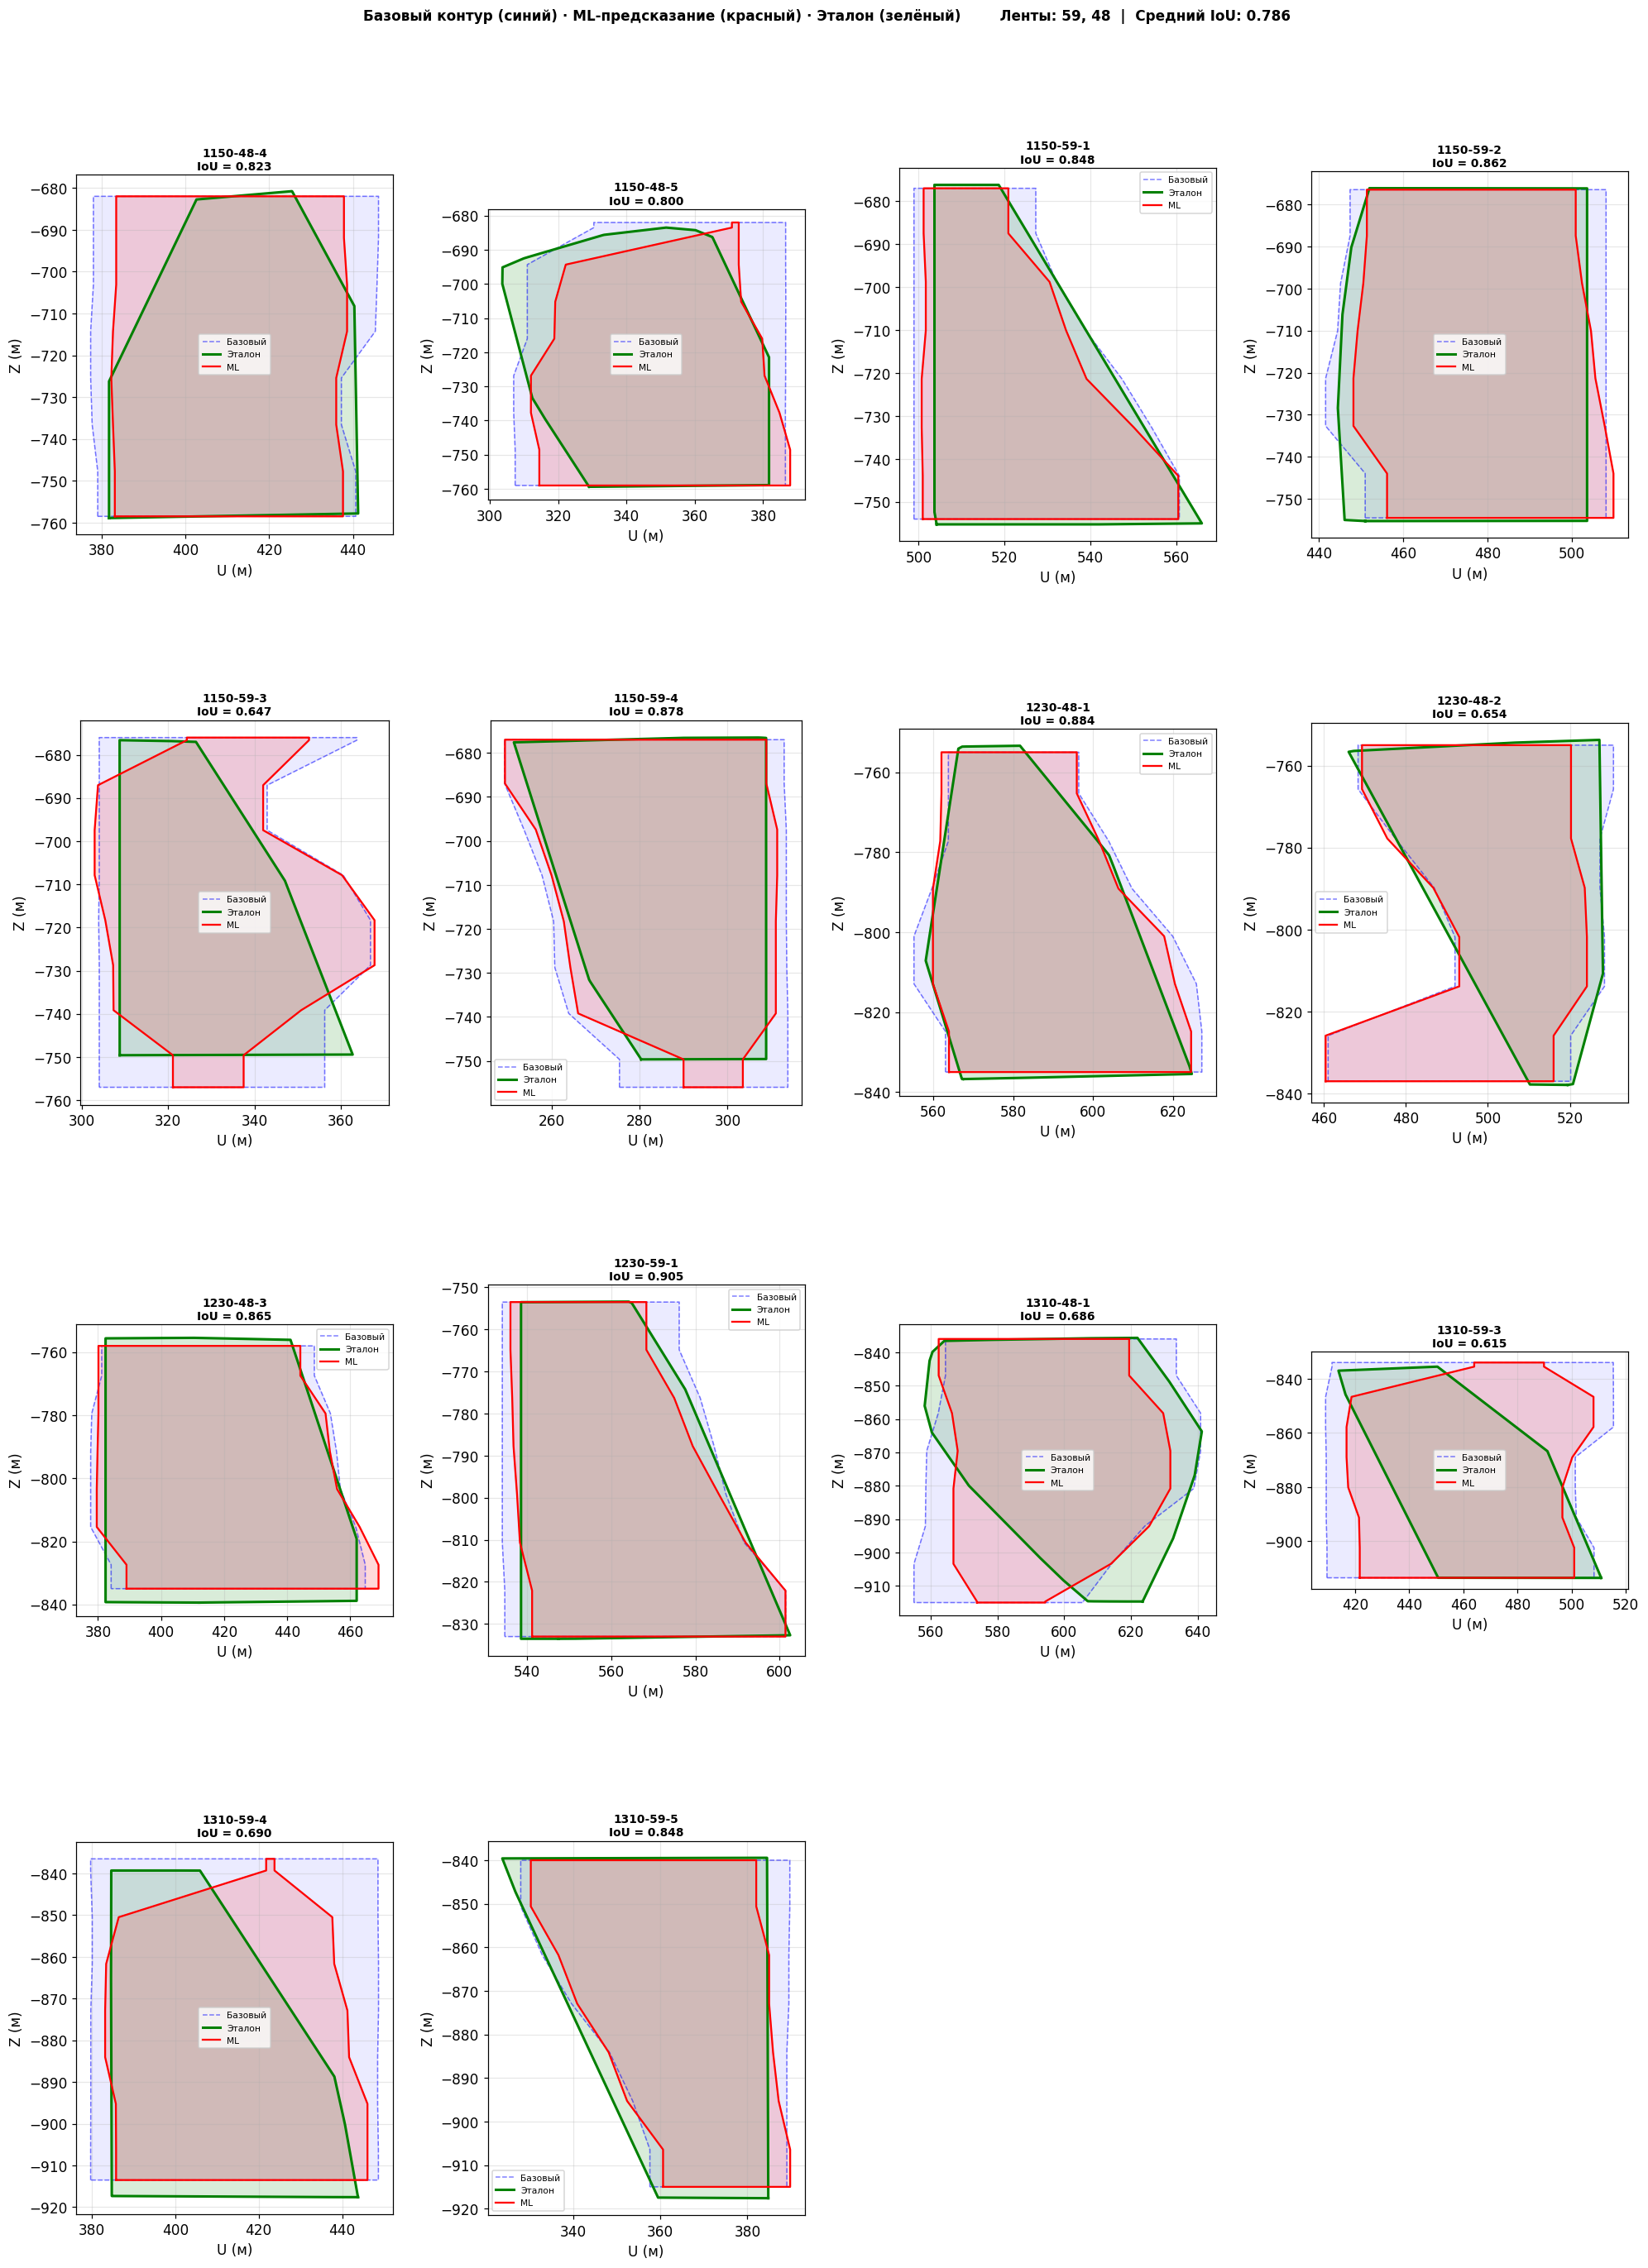

In [18]:
# ── Визуализация каркасов (логика из test_wireframe.py) ──────────────────────

n_zones = len(profiles)
cols = min(4, n_zones)
rows = (n_zones + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 6.5 * rows))
fig.subplots_adjust(hspace=0.45, wspace=0.3, top=0.91, bottom=0.04)

if n_zones == 1: axes = np.array([axes])
axes = np.array(axes).flatten()

for idx, p in enumerate(profiles):
    ax = axes[idx]
    ax.fill(p['base'][:,0], p['base'][:,1], alpha=0.08, color='blue')
    ax.plot(p['base'][:,0], p['base'][:,1], 'b--', alpha=0.5, lw=1,   label='Базовый')
    ax.fill(p['ref'][:,0],  p['ref'][:,1],  alpha=0.15, color='green')
    ax.plot(p['ref'][:,0],  p['ref'][:,1],  'g-',  lw=2,   label='Эталон')
    ax.fill(p['ml'][:,0],   p['ml'][:,1],   alpha=0.15, color='red')
    ax.plot(p['ml'][:,0],   p['ml'][:,1],   'r-',  lw=1.5, label='ML')
    ax.set_title(f"{p['zone_id']}\nIoU = {p['iou']:.3f}",
                 fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel('U (м)'); ax.set_ylabel('Z (м)')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3); ax.set_aspect('equal')

for idx in range(n_zones, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    f"Базовый контур (синий) · ML-предсказание (красный) · Эталон (зелёный)"
    f"        Ленты: {', '.join(TEST_RIBBONS)}  |  Средний IoU: {np.mean(ious):.3f}",
    fontsize=11, fontweight='bold', y=0.975
)
plt.show()

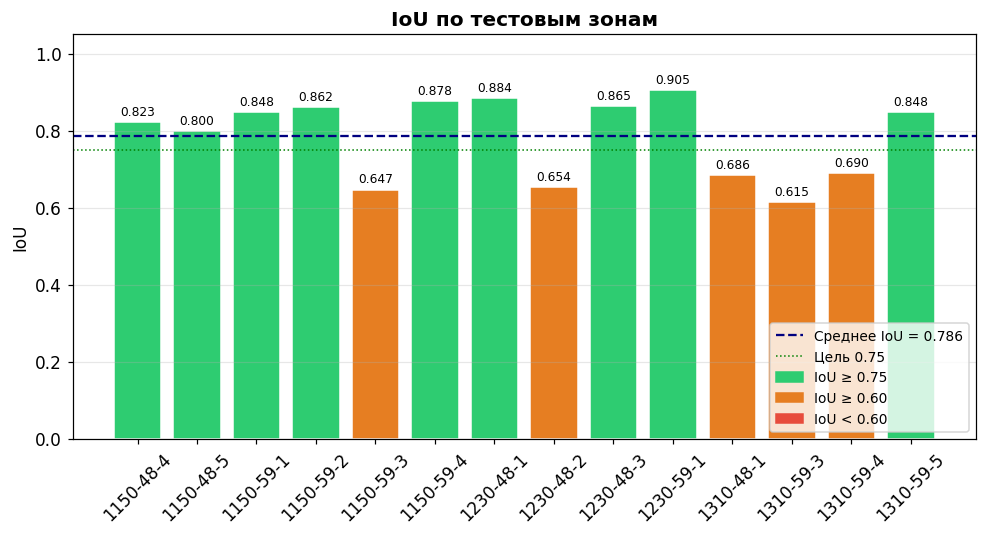

In [19]:
# IoU по зонам — столбчатая диаграмма
zone_labels = [p['zone_id'] for p in profiles]
iou_vals    = [p['iou']     for p in profiles]
bar_colors  = ['#2ecc71' if v >= 0.75 else '#e67e22' if v >= 0.60 else '#e74c3c' for v in iou_vals]

fig, ax = plt.subplots(figsize=(max(8, n_zones * 0.65), 5))
bars = ax.bar(zone_labels, iou_vals, color=bar_colors, edgecolor='white')
ax.axhline(np.mean(iou_vals), color='navy', linestyle='--', lw=1.5,
           label=f'Среднее IoU = {np.mean(iou_vals):.3f}')
ax.axhline(0.75, color='green', linestyle=':', lw=1, label='Цель 0.75')
ax.set_ylim(0, 1.05); ax.set_ylabel('IoU')
ax.set_title('IoU по тестовым зонам', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, iou_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
patches = [
    mpatches.Patch(color='#2ecc71', label='IoU ≥ 0.75'),
    mpatches.Patch(color='#e67e22', label='IoU ≥ 0.60'),
    mpatches.Patch(color='#e74c3c', label='IoU < 0.60'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Выводы

### 7.1 Что дала Z-level архитектура (Feature Engineering)

Переход от «1 строка на секцию → 18 целей» к «1 строка на Z-уровень → 4 цели» дал **+50% IoU** (с 0.52 до 0.786).

Три причины:
1. **Поуровневые признаки.** Модель видит геометрию рудной зоны на конкретном уровне k, а не усредненную по всей секции. `ore_u_left_k`, `ore_u_right_k`, `grade_outer_left_k` — самые важные признаки по feature importance.

2. **Контекст соседних уровней (`_prev`/`_next`).** Проектировщик при построении борта смотрит, где рудная зона на уровне выше и ниже. Признаки `ore_u_left_prev`, `ore_u_right_prev` входят в топ-5 по важности.

3. **Больше обучающих примеров.** 4888 строк вместо 611 — модель лучше обобщается на новые ленты.

### 7.2 Почему выбран именно такой набор признаков

| Группа | Обоснование |
|---|---|
| `ore_u_left/right`, `ore_width` | Прямая геометрия рудного тела — главный сигнал |
| `grade_outer_left/right` | Содержание **вне** базового контура — решение «включить ли борт» |
| `grade_inner_left/right` | Содержание у борта изнутри — компромисс разубоживание/потери |
| `max_gap`, `ore_continuity` | Прерывистость рудной зоны — «тянуться ли через прослойку» |
| `left_fringe`, `right_fringe` | Выступающие рудные блоки за базовым контуром |
| `_prev`, `_next` | Связность по вертикали — дельты соседних уровней коррелируют |
| `subcutoff_fraction`, `grade_top_ratio` | Глобальное качество рудного тела |

### 7.3 Как боролись с переобучением

1. **Разделение по лентам** (`split_by_ribbon`): тестовые ленты 59 и 48 полностью исключены из обучения. Случайный split по строкам давал завышенный IoU ~0.92 на тесте — это была утечка данных.

2. **Сильная L2-регуляризация** (`reg_lambda=5.0`): при 4888 строках и 33 признаках малая глубина деревьев (max_depth=3) в сочетании с высокой регуляризацией не даёт модели запомнить нюансы конкретных лент.

3. **Subsampling** (`subsample=0.8`, `colsample_bytree=0.8`): каждое дерево видит 80% данных и 80% признаков — снижает корреляцию между деревьями.

4. **Обнуление `delta_floor`/`delta_roof`** на инференсе: R² этих целей на тесте отрицательный (модель хуже константного предсказания) — использование нулевой дельты дало лучший IoU, чем ML-предсказание.

### 7.4 Итог

| Метрика | Значение |
|---|---|
| Средний IoU (тест, ленты 59+48) | **0.786** |
| MAE delta_left (тест) | ~6–8 м |
| MAE delta_right (тест) | ~6–8 м |
| Время расчёта 1 каркаса | < 1 сек (vs ~2 часа вручную) |
